In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import gym
import os
import cityflow
import gym_cityflow
import random

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [3]:
class DQN_network(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dims=[128, 256, 128]):
        super(DQN_network, self).__init__()

        self.fc_1 = nn.Linear(input_dim, hidden_dims[0])
        self.norm1 = nn.LayerNorm(hidden_dims[0])

        self.fc_2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.norm2 = nn.LayerNorm(hidden_dims[1])

        self.fc_3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.norm3 = nn.LayerNorm(hidden_dims[2])

        self.out = nn.Linear(hidden_dims[2], action_dim)

    def forward(self, x):
        x = F.relu(self.norm1(self.fc_1(x)))
        x = F.relu(self.norm2(self.fc_2(x)))
        x = F.relu(self.norm3(self.fc_3(x)))
        q_values = self.out(x)
        return q_values

In [4]:
class MultiAgentReplayBuffer:
    def __init__(self, max_size, num_agents, obs_dim):
        self.max_size = max_size
        self.num_agents = num_agents
        self.obs_dim = obs_dim
        self.idx = 0
        self.size = 0
        self.states      = np.zeros((max_size, num_agents, obs_dim), dtype=np.float32)
        self.next_states = np.zeros((max_size, num_agents, obs_dim), dtype=np.float32)
        self.actions     = np.zeros((max_size, num_agents), dtype=np.int64)
        self.rewards     = np.zeros((max_size, num_agents), dtype=np.float32)
        self.dones       = np.zeros(max_size, dtype=np.float32)

    def store(self, states, actions, next_states, rewards, done):
        self.states[self.idx]      = states
        self.next_states[self.idx] = next_states
        self.actions[self.idx]     = actions
        self.rewards[self.idx]     = rewards
        self.dones[self.idx]       = done
        self.idx = (self.idx + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (
            self.states[idxs],
            self.actions[idxs],
            self.rewards[idxs],
            self.next_states[idxs],
            self.dones[idxs]
        )

    def __len__(self):
        return self.size

In [5]:
class DQNAgentManager:
    def __init__(self, obs_dim, action_dim, num_agents, buffer_size=15000, batch_size=128, train_freq=4, target_update_freq=8, 
    lr=1e-4, gamma=0.8, epsilon_start=1.0, epsilon_min=0.25, epsilon_decay= None, reward_norm_momentum=1e-3, reward_norm_eps=1e-8, max_grad_norm=1.0
    ):
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.num_agents = num_agents
        self.batch_size = batch_size
        self.train_freq = train_freq
        self.target_update_freq = target_update_freq
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.r_mean     = 0.0
        self.r_var      = 1.0
        self.r_momentum = reward_norm_momentum
        self.r_eps      = reward_norm_eps
        self.max_grad_norm = max_grad_norm
        self.q_net = DQN_network(obs_dim, action_dim).to(device)
        self.target_net = DQN_network(obs_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.replay_buffer = MultiAgentReplayBuffer(buffer_size, num_agents, obs_dim)

        self.step_count = 0

    def select_actions(self, obs_batch):
        actions = []
        for obs in obs_batch:
            if np.random.rand() < self.epsilon:
                actions.append(np.random.randint(self.action_dim))
            else:
                with torch.no_grad():
                    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                    q = self.q_net(obs_t)
                    actions.append(q.argmax().item())
        return actions

    def store_transition(self, states, actions, next_states, rewards, done):
        raw = np.array(rewards, dtype=np.float32).flatten()
        batch_mean = raw.mean()
        batch_var  = raw.var()
        delta = batch_mean - self.r_mean
        self.r_mean += self.r_momentum * delta
        self.r_var  += self.r_momentum * (batch_var - self.r_var)

        normed = (raw - self.r_mean) / (np.sqrt(self.r_var) + self.r_eps)
        normed = normed.reshape(len(rewards))
        self.replay_buffer.store(states, actions, next_states, normed, done)

    def step(self):
        self.step_count += 1
        if len(self.replay_buffer) >= self.batch_size and self.step_count % self.train_freq == 0:
            self._learn()
        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

    def end_episode(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def _learn(self):
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        bs, na, od = states.shape

        s = torch.FloatTensor(states.reshape(bs*na, od)).to(device)
        a  = torch.LongTensor(actions.reshape(bs*na, 1)).to(device)
        r  = torch.FloatTensor(rewards.reshape(bs*na, 1)).to(device)
        s2 = torch.FloatTensor(next_states.reshape(bs*na, od)).to(device)
        d  = torch.FloatTensor(dones.repeat(na).reshape(bs*na, 1)).to(device)

        q_vals = self.q_net(s).gather(1, a)
        with torch.no_grad():
            q_next = self.target_net(s2).max(1, keepdim=True)[0]
            target = r + self.gamma * q_next * (1 - d)

        loss = F.mse_loss(q_vals, target)
        self.optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), self.max_grad_norm)
        self.optimizer.step()


In [6]:
def train_multi_dqn(
    config_path,
    num_agents=16,
    obs_dim=72,
    action_dim=9,
    num_episodes=500,
    max_steps_per_episode=1000,
    buffer_size=15000,
    batch_size=128,
    train_freq=4,
    target_update_freq=8,
    gamma=0.8,
    lr=1e-4,
    epsilon_start=1.0,
    epsilon_min=0.25,
    epsilon_decay=None,
    checkpoint_interval=250, 
    checkpoint_dir="checkpoints"
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    env = gym.make(
        id='cityflow-v0',
        configPath=config_path,
        episodeSteps=max_steps_per_episode
    )
    raw_obs = env.reset()
    intersection_ids = sorted(raw_obs.keys())

    epsilon_decay = (epsilon_min / epsilon_start) ** (1.0 / num_episodes)

    agent_mgr = DQNAgentManager(
        obs_dim=obs_dim,
        action_dim=action_dim,
        num_agents=num_agents,
        buffer_size=buffer_size,
        batch_size=batch_size,
        train_freq=train_freq,
        target_update_freq=target_update_freq,
        lr=lr,
        gamma=gamma,
        epsilon_start=epsilon_start,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay
    )

    rewards_history = []

    for ep in range(1, num_episodes + 1):
        seed_val = np.random.randint(0, 1_000_000)
        env.seed(seed_val)
        raw_obs = env.reset()
        obs = [np.array(raw_obs[k], dtype=np.float32).flatten() for k in intersection_ids]
        total_reward = 0

        for t in range(max_steps_per_episode):
            actions = agent_mgr.select_actions(obs)
            next_raw_obs, rewards, done, _ = env.step(actions)
            next_obs = [np.array(next_raw_obs[k], dtype=np.float32).flatten() for k in intersection_ids]
            reward_dict   = {key: val for key, val in rewards}
            rewards_list  = [reward_dict[k] for k in intersection_ids]
            total_reward += sum(rewards_list)

            agent_mgr.store_transition(obs, actions, next_obs, rewards_list, done)
            agent_mgr.step()

            obs = next_obs
            if done:
                break

        agent_mgr.end_episode()
        rewards_history.append(total_reward)
        print(f"Episode {ep:4d} | Steps {t:3d} | Reward {total_reward:.1f} | Epsilon {agent_mgr.epsilon:.3f}")

        if ep % checkpoint_interval == 0:
            ckpt_path = os.path.join(checkpoint_dir, f"qnet_dqn_ep{ep}.pth")
            torch.save(agent_mgr.q_net.state_dict(), ckpt_path)
            print(f"Checkpoint SAVED")

    final_path = os.path.join(checkpoint_dir, "qnet_dqn_final.pth")
    torch.save(agent_mgr.q_net.state_dict(), final_path)
    print(f"Model saved to {final_path}")

    plt.plot(rewards_history)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Multi-Agent DQN Training")
    plt.show()

    env.close()

/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'dict'>`
  logger.warn(
/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core env

Episode    1 | Steps 998 | Reward -5134323.0 | Epsilon 0.997
Episode    2 | Steps 998 | Reward -5307993.0 | Epsilon 0.994
Episode    3 | Steps 998 | Reward -5317374.0 | Epsilon 0.992
Episode    4 | Steps 998 | Reward -5067630.0 | Epsilon 0.989
Episode    5 | Steps 998 | Reward -4958361.0 | Epsilon 0.986
Episode    6 | Steps 998 | Reward -5009043.0 | Epsilon 0.984
Episode    7 | Steps 998 | Reward -5318664.0 | Epsilon 0.981
Episode    8 | Steps 998 | Reward -4707078.0 | Epsilon 0.978
Episode    9 | Steps 998 | Reward -5025045.0 | Epsilon 0.975
Episode   10 | Steps 998 | Reward -5056161.0 | Epsilon 0.973
Episode   11 | Steps 998 | Reward -4864512.0 | Epsilon 0.970
Episode   12 | Steps 998 | Reward -4433295.0 | Epsilon 0.967
Episode   13 | Steps 998 | Reward -4328958.0 | Epsilon 0.965
Episode   14 | Steps 998 | Reward -4695966.0 | Epsilon 0.962
Episode   15 | Steps 998 | Reward -4812030.0 | Epsilon 0.959
Episode   16 | Steps 998 | Reward -4345227.0 | Epsilon 0.957
Episode   17 | Steps 998

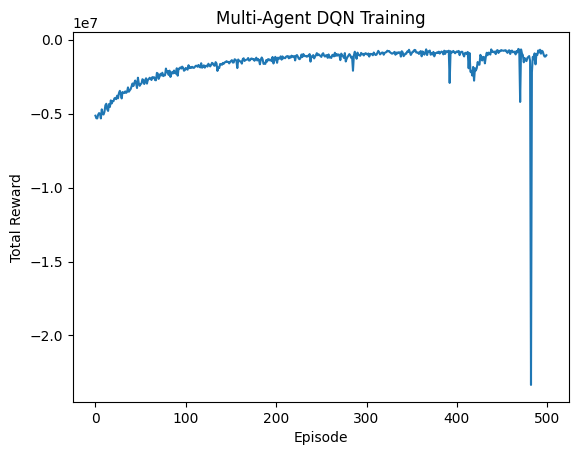

In [7]:
train_multi_dqn("Intersections_4/sample_config.json")